In [13]:
# 1. Imports & setup
import math, time, json, copy
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset

dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print(dev, torch.cuda.get_device_name(0) if dev=='cuda' else '')
torch.manual_seed(1337)


cuda Tesla T4


In [14]:
# 2. Data: 120M bytes of WikiText-103 (byte-level, V=256). Total tokens seen per model stays < 1 epoch.
ds=load_dataset('Salesforce/wikitext','wikitext-103-raw-v1',split='train')
buf=bytearray()
for t in ds['text']:
    buf+=t.encode('utf-8','ignore')
    if len(buf)>=120_000_000: break
data=torch.from_numpy(np.frombuffer(bytes(buf),dtype=np.uint8).copy()); V=256   # byte-level
n=int(.99*len(data)); tr,va=data[:n],data[n:]
print('chars',len(data),'train',len(tr),'val',len(va))
B,T=64,256
def batch(split):
    d=tr if split=='train' else va
    ix=torch.randint(len(d)-T-1,(B,))
    x=torch.stack([d[i:i+T] for i in ix]); y=torch.stack([d[i+1:i+T+1] for i in ix])
    return x.to(dev).long(),y.to(dev).long()


chars 120000249 train 118800246 val 1200003


In [15]:
# 3. Dense GPT
class MLP(nn.Module):
    def __init__(s,d):
        super().__init__(); s.fc=nn.Linear(d,4*d); s.proj=nn.Linear(4*d,d)
    def forward(s,x): return s.proj(F.gelu(s.fc(x)))

class Block(nn.Module):
    def __init__(s,d,h):
        super().__init__(); s.h=h
        s.ln1=nn.LayerNorm(d); s.qkv=nn.Linear(d,3*d); s.o=nn.Linear(d,d)
        s.ln2=nn.LayerNorm(d); s.mlp=MLP(d)
    def forward(s,x):
        Bz,Tz,D=x.shape
        q,k,v=s.qkv(s.ln1(x)).view(Bz,Tz,3,s.h,D//s.h).permute(2,0,3,1,4)
        a=F.scaled_dot_product_attention(q,k,v,is_causal=True).transpose(1,2).reshape(Bz,Tz,D)
        x=x+s.o(a); return x+s.mlp(s.ln2(x))

class GPT(nn.Module):
    def __init__(s,V,d=384,L=6,h=6):
        super().__init__()
        s.tok=nn.Embedding(V,d); s.pos=nn.Embedding(T,d)
        s.blocks=nn.ModuleList([Block(d,h) for _ in range(L)]); s.ln=nn.LayerNorm(d); s.head=nn.Linear(d,V)
    def forward(s,x,y=None):
        h=s.tok(x)+s.pos(torch.arange(x.shape[1],device=x.device))
        for b in s.blocks: h=b(h)
        lg=s.head(s.ln(h)); loss=F.cross_entropy(lg.view(-1,lg.size(-1)),y.view(-1)) if y is not None else None
        return lg,loss
    def aux(s): return sum(b.mlp.aux for b in s.blocks if isinstance(b.mlp,MoE))


In [16]:
# 4. MoE layer + dense->MoE conversion (sparse upcycling) + param counts
class MoE(nn.Module):
    """Top-k routed MoE. Experts are initialised from a dense MLP (sparse upcycling)."""
    def __init__(s,mlp,E=8,k=2,noise=0.01):
        super().__init__(); d=mlp.fc.in_features
        s.E,s.k=E,k
        s.experts=nn.ModuleList()
        for _ in range(E):
            e=copy.deepcopy(mlp)
            with torch.no_grad():
                for p in e.parameters(): p.add_(noise*p.std()*torch.randn_like(p))
            s.experts.append(e)
        s.router=nn.Linear(d,E,bias=False); nn.init.normal_(s.router.weight,std=0.02)
        s.aux=0.
    def forward(s,x):
        Bz,Tz,D=x.shape; xf=x.reshape(-1,D)
        probs=F.softmax(s.router(xf),-1)
        w,idx=probs.topk(s.k,-1); w=w/w.sum(-1,keepdim=True)
        out=torch.zeros_like(xf)
        for e in range(s.E):
            tok,slot=(idx==e).nonzero(as_tuple=True)
            if tok.numel()==0: continue
            out.index_add_(0,tok,s.experts[e](xf[tok])*w[tok,slot,None])
        # switch-style load balancing loss
        frac=F.one_hot(idx[:,0],s.E).float().mean(0); s.aux=s.E*(frac*probs.mean(0)).sum()
        return out.reshape(Bz,Tz,D)

def upcycle(model,E=8,k=2):
    m=copy.deepcopy(model)
    for b in m.blocks: b.mlp=MoE(b.mlp,E,k)
    return m.to(dev)

nparams=lambda m:sum(p.numel() for p in m.parameters())
def active_params(m):
    tot=nparams(m)
    for b in m.blocks:
        if isinstance(b.mlp,MoE): tot-=nparams(b.mlp.experts[0])*(b.mlp.E-b.mlp.k)
    return tot


In [17]:
# 5. Evaluation & training loop
@torch.no_grad()
def evaluate(m,iters=20):
    m.eval(); out={}
    for sp in ('train','val'):
        out[sp]=sum(m(*batch(sp))[1].item() for _ in range(iters))/iters
    m.train(); return out

def run(m,steps,lr,tag,log,start=0,warm=100,aux_w=0.01,ev=100):
    opt=torch.optim.AdamW(m.parameters(),lr=lr,betas=(.9,.99),weight_decay=0.1)
    t0=time.time()
    bf16=dev=='cuda' and torch.cuda.get_device_capability()[0]>=8   # T4 has no native bf16 -> use fp16 + GradScaler
    scaler=torch.amp.GradScaler(enabled=(dev=='cuda' and not bf16))
    for i in range(steps):
        cur=lr*min(1,(i+1)/warm)*(0.1+0.9*0.5*(1+math.cos(math.pi*i/steps)))
        for g in opt.param_groups: g['lr']=cur
        x,y=batch('train')
        with torch.autocast(dev,dtype=torch.bfloat16 if bf16 else torch.float16,enabled=dev=='cuda'):
            _,loss=m(x,y); tot=loss+(aux_w*m.aux() if tag!='dense' else 0)
        opt.zero_grad(set_to_none=True); scaler.scale(tot).backward(); scaler.unscale_(opt); nn.utils.clip_grad_norm_(m.parameters(),1.); scaler.step(opt); scaler.update()
        if i%ev==0 or i==steps-1:
            e=evaluate(m); log.append(dict(step=start+i,phase=tag,train=e['train'],val=e['val']))
            print(f"{tag:10s} step {start+i:5d} train {e['train']:.4f} val {e['val']:.4f} ({time.time()-t0:.0f}s)")


In [ ]:
# 6. Phase 1: train the dense model
dense=GPT(V).to(dev); print('dense params',nparams(dense)/1e6,'M')
log=[]
DENSE_STEPS,MOE_STEPS=2000,1500
run(dense,DENSE_STEPS,1e-3*1.0,'dense',log)
dense_final=copy.deepcopy(dense.state_dict())


dense params 10.94272 M
dense      step     0 train 5.7130 val 5.7113 (5s)
dense      step   100 train 2.4667 val 2.4862 (23s)
dense      step   200 train 2.3153 val 2.3231 (40s)
dense      step   300 train 1.9728 val 1.9862 (57s)
dense      step   400 train 1.7766 val 1.7842 (74s)
dense      step   500 train 1.6529 val 1.6621 (91s)
dense      step   600 train 1.5631 val 1.5783 (108s)


In [ ]:
# 7. Convert the trained dense model to an MoE
moe=upcycle(dense)
print('MoE total params',nparams(moe)/1e6,'M; active/token',active_params(moe)/1e6,'M')
e0=evaluate(moe); print('right after conversion:',e0, '| dense before:',log[-1])
log.append(dict(step=DENSE_STEPS,phase='moe',train=e0['train'],val=e0['val']))
ctrl=copy.deepcopy(dense); clog=[dict(step=DENSE_STEPS,phase='dense_cont',train=log[-1]['train'],val=log[-1]['val'])]


In [11]:
# 8. Phase 2: keep training the MoE; dense control gets the same budget
run(moe,MOE_STEPS,3e-4,'moe',log,start=DENSE_STEPS+1)
run(ctrl,MOE_STEPS,3e-4,'dense_cont',clog,start=DENSE_STEPS+1)


moe        step  2001 train 1.2611 val 1.2869 (10s)
moe        step  2101 train 1.2837 val 1.2887 (107s)
moe        step  2201 train 1.2757 val 1.2963 (205s)
moe        step  2301 train 1.2752 val 1.2826 (302s)
moe        step  2401 train 1.2632 val 1.2830 (400s)
moe        step  2501 train 1.2436 val 1.2678 (497s)
moe        step  2601 train 1.2436 val 1.2585 (595s)
moe        step  2701 train 1.2364 val 1.2544 (692s)
moe        step  2801 train 1.2165 val 1.2452 (790s)
moe        step  2901 train 1.2104 val 1.2424 (887s)
moe        step  3001 train 1.2138 val 1.2226 (985s)
moe        step  3101 train 1.1936 val 1.2277 (1082s)
moe        step  3201 train 1.1996 val 1.2143 (1180s)
moe        step  3301 train 1.1888 val 1.2145 (1277s)
moe        step  3401 train 1.1848 val 1.2140 (1375s)
moe        step  3500 train 1.1842 val 1.2085 (1471s)
dense_cont step  2001 train 1.2653 val 1.2872 (6s)
dense_cont step  2101 train 1.2810 val 1.2961 (64s)
dense_cont step  2201 train 1.2779 val 1.2897

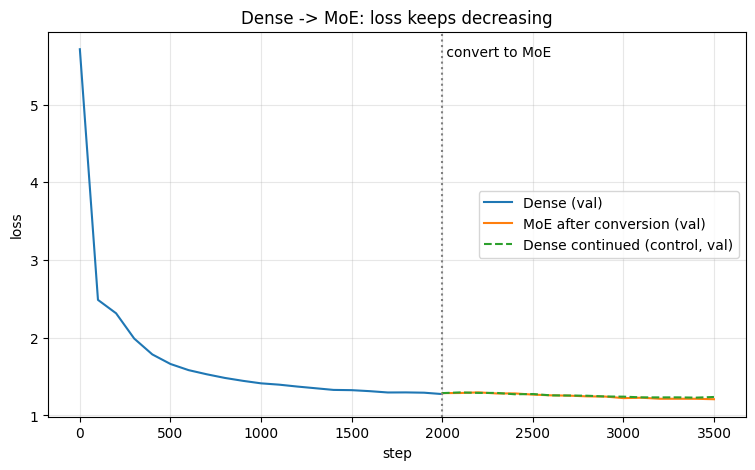

dense end 1.2748793423175813 | moe start 1.2820822656154633 | moe end 1.2084822535514832 | control end 1.2373012244701385


In [12]:
# 9. Plot loss curves & save results
d=[r for r in log if r['phase']=='dense']; m=[r for r in log if r['phase']=='moe']
plt.figure(figsize=(9,5))
plt.plot([r['step'] for r in d],[r['val'] for r in d],label='Dense (val)')
plt.plot([r['step'] for r in m],[r['val'] for r in m],label='MoE after conversion (val)')
plt.plot([r['step'] for r in clog],[r['val'] for r in clog],'--',label='Dense continued (control, val)')
plt.axvline(DENSE_STEPS,color='gray',ls=':'); plt.text(DENSE_STEPS,plt.ylim()[1]*.97,' convert to MoE',va='top')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend(); plt.grid(alpha=.3); plt.title('Dense -> MoE: loss keeps decreasing')
plt.savefig('loss_curve.png',dpi=130,bbox_inches='tight'); plt.show()
json.dump(dict(log=log,control=clog,dense_params=nparams(dense),moe_params=nparams(moe),moe_active=active_params(moe)),open('results.json','w'),indent=1)
print('dense end',d[-1]['val'],'| moe start',m[0]['val'],'| moe end',m[-1]['val'],'| control end',clog[-1]['val'])